# 小麥種子資料集：分群與迴歸分析

本專案使用 UCI Machine Learning Repository 的小麥核仁資料集，透過 X 光量測七項幾何特徵（面積、周長、緊密度、長度、寬度、不對稱係數、核仁槽長度），分別以 **K-Means 分群** 和 **簡單線性迴歸** 兩種機器學習方法探索資料結構與特徵間的線性關係。

**資料來源：** [UCI Seeds Dataset](https://archive.ics.uci.edu/dataset/236/seeds)  
**主要技術：** NumPy、Pandas、Scikit-learn、Matplotlib

# 分群分析（Clustering）

## 手刻 K-Means：

從零實作 Lloyd's Algorithm，完整涵蓋三個核心步驟：
- ****：對每個資料點計算到各群中心的歐氏距離平方，取最近的群標籤
- ****：對各群的資料點取平均，更新群中心
- ****：計算所有資料點到其群中心的距離平方總和（慣性）

 迭代上述三步直到群標籤不再改變為止，同時支援固定隨機種子以利重現結果。

In [106]:
# Codegrade Tag Question1
# Do *not* remove the tag above
# Implement the class below

import numpy as np

class KMeansManual:
    """
    Implements Lloyd's algorithm for k-means clustering.

    Member variables:
    - n_clusters : int, the parameter k (number of clusters)
    - init : array, optional, initial clusters (or none)
    - n_feature_in_ : int, length of vectors
    - labels_ : array of integers of length n, after fitting, the cluster labels of the dataset
    - cluster_centers_ : array of shape n*d, the fitted cluster centers
    - inertia_ : float, sum of squared euclidean distances from each datapoint to the associated cluster center
    """

    def __init__(self, n_clusters, init = None, random_state = None):
        """
        Constructor, sets the parameters

        Parameters:
        - n_clusters : int, the parameter k (number of clusters)
        - init : array, optional, initial clusters; if None, clusters will be randomly initialized by selecting k random points from the dataset during fit(); otherwise, must be an array of shape k*d and the number of features in the dataset must match d
        - random state : integer, optional, if init is not None, this parameter is ignored; sets the random number seed for selecting the random datapoints
        """
        assert n_clusters > 0
        self.n_clusters = n_clusters
        self.random_state = random_state
        if init is not None:
            assert init.ndim == 2
            assert init.shape[0] == n_clusters
            self.init = init.copy()
        else:
            self.init = None

    def assign_labels(self, X, cluster_centers):
        """
        Given the n*d dataset X, returns an integer array of length n where each element has value 0, 1, ..., k-1, to indicate the index of the closest cluster center (in terms of squared Euclidean distance)

        Parameters:
        - X : array, n*d dataset
        - cluster_centers : array of shape k*d, present cluster centers

        Return value:
        - an integer array of length n where the ith element corresponds to the cluster label of the closest cluster center of that datapoint
        """
        assert isinstance(X,np.ndarray)
        assert isinstance(cluster_centers,np.ndarray)
        assert X.ndim == 2 and cluster_centers.ndim == 2
        assert cluster_centers.shape[0] == self.n_clusters
        assert X.shape[1] == cluster_centers.shape[1]

        cluster_labels = [] #initiate a list for the return values
        for x in X: #loop throug all elements of the dataset X
            distances = [] #initiate a list for the different distances to the cluster centers
            for center in cluster_centers: #loop throug all cluster centers
                distance = 0.0 #initializ distance
                for d in range(len(X[0])): #loop throug each feature
                    distance += (x[d] - center[d])**2 #calculate the square distances
                distances.append(distance) #append the square distance to each cluster to a list
            cluster_labels.append(int(np.argmin(distances))) #get the index of the minimum distance and add that the the return array
                                         
        return np.array(cluster_labels)

    def compute_cluster_centers(self, X, labels):
        """
        Determine the cluster centroids, that is, the mean of the vectors associated with the same cluster label.

        Parameters:
        - X : array of shape n*d, the dataset
        - labels : 1-dimensional integer array of length n, the present label assignments

        Return value:
        - An array of shape k*d, the current cluster centers
        """
        assert isinstance(X,np.ndarray)
        assert isinstance(labels,np.ndarray)
        assert X.ndim == 2
        assert labels.ndim == 1
        assert X.shape[0] == labels.shape[0]
        
        #getting the dimentions
        n, d = X.shape
        k = self.n_clusters

        #make the return list of clusters
        centered_cluster = np.zeros((k, d))

        for c in range(k): #run throug all the cluster labels
            members = X[labels == c]
            centered_cluster[c] = np.mean(members, axis = 0)

        return centered_cluster

    def compute_inertia(self, X, labels, cluster_centers):
        """
        Given the n*d dataset, the n-vector of cluster labels, and the k*d array of cluster centers, computes the inertia, that is, the sum of squared Euclidean distances from each datapoint to the closest cluster center (as identified by the cluster label)

        Parameters:
        - X : array of shape n*d, the dataset
        - labels : integer array of length n, the cluster labels of each datapoint
        - cluster_centers : array of shape k*d, the present cluster centers

        Return value:
        - float, the sum of squared euclidean distances to closest cluster centers
        """
        assert isinstance(X,np.ndarray)
        assert isinstance(cluster_centers,np.ndarray)
        assert isinstance(labels,np.ndarray)
        assert X.ndim == 2 and cluster_centers.ndim == 2
        assert labels.ndim == 1
        assert cluster_centers.shape[0] == self.n_clusters
        assert X.shape[0] == labels.shape[0]
        assert X.shape[1] == cluster_centers.shape[1]
        
        inertia = 0.0 #initialize inertia

        for x_idx, x in enumerate(X): #loop throug all points in Dataset
            closes_center_idx = labels[x_idx] #get the closest center incex
            dist = 0.0 #initialize distance
            for j in range(len(x)): #run throug all fetures
                dist += (x[j] - cluster_centers[closes_center_idx][j])**2 #calculate the square distance for each feature and add it to total distance
            inertia += dist #add each distance to the inertia
        
        return inertia



    def fit(self,X):
        """
        Fit the dataset X, that is, compute the cluster centers and assignments.

        Parameters:
        - X : n*d array of observations; if init was not None, then d must match the second axis of init; otherwise, k random row vectors are picked from X to serve as initial clusters (if random_state was not None, then the same choice should always be made)

        Return value:
        - Returns self
        """

        n, d = X.shape

        self.n_features_in_ = n

        if self.init is not None:
            cluster_centers = self.init
        else:
            if self.random_state is not None:
                rng = np.random.default_rng(self.random_state)
            else:
                rng = np.random.default_rng()
            indices = rng.choice(n, size=self.n_clusters, replace=False)
            cluster_centers = X[indices].copy()

        labels = None
        inertia = None

        while True:

            new_labels = np.array(self.assign_labels(X, cluster_centers))

            new_centers = self.compute_cluster_centers(X, new_labels)

            new_inetria = self.compute_inertia(X, new_labels, new_centers)

            if labels is not None and np.array_equal(new_labels, labels):
                break

            labels = new_labels
            cluster_centers = new_centers
            inertia = new_inetria
        
        self.labels_ = labels
        self.cluster_centers_ = cluster_centers
        self.inertia_ = inertia
        
        return self




## 資料讀取與標準化

從 （Tab 分隔）讀入資料，命名八個欄位後，以  對前七個特徵做 Z-score 標準化（使用有偏變異數估計），取得特徵矩陣 （210×7）與類別標籤向量 。

In [107]:
# Codegrade Tag Question2
# Do *not* remove the tag above
import pandas as pd
from sklearn.preprocessing import StandardScaler

column_names = ["area",                    
                "perimeter",
                "compactness",
                "length",
                "width",
                "asymmetry coefficient",
                "length of kernel groove",
                "class"]

df = pd.read_table("seeds.tsv", header = None, names = column_names)

X_not_norm = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X = StandardScaler().fit_transform(X_not_norm)

print(X.shape)


(210, 7)


## 資料視覺化

多維資料難以直接觀察，以下三種方式將七維資料投影到二維空間，再以類別上色，直觀感受三種小麥的群體分佈。

### 特徵對散佈圖

直接繪製原始（標準化後）特徵的兩兩散佈圖。面積與周長這對特徵呈現明顯的線性正相關，且三個類別在此空間已能相當程度地分開，說明這兩個幾何量具有良好的判別能力。

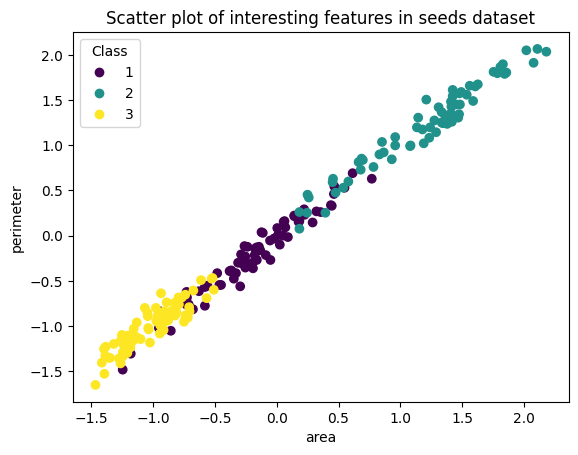

In [108]:
# Codegrade Tag Question3a
# Do *not* remove the tag above
import matplotlib.pyplot as plt

#create list of features:
X_transposed = X.T

fig, ax = plt.subplots()
scatter = ax.scatter(X_transposed[0], X_transposed[1], c=y)

ax.legend(
    *scatter.legend_elements(),
    title="Class"
)

interesting_feature1 = df.columns[0]
interesting_feature2 = df.columns[1]


ax.set_xlabel(interesting_feature1)
ax.set_ylabel(interesting_feature2)
ax.set_title("Scatter plot of interesting features in seeds dataset")

plt.show()

### 主成分分析（PCA）

PCA 找出資料變異最大的正交方向。前兩個主成分合計解釋了大部分的變異，投影後三類幾乎不重疊，代表資料在低維空間中即有清晰的線性可分結構。

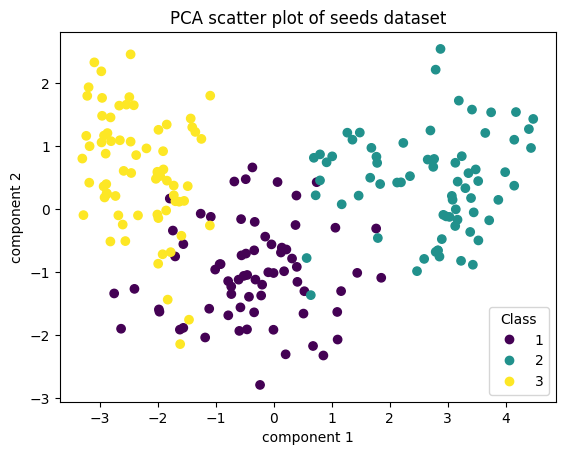

In [109]:
# Codegrade Tag Question3b
# Do *not* remove the tag above
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_components = pca.components_
pca_explained_variance = np.sum(pca.explained_variance_ratio_)

#print(pca_components)
#print(pca_explained_variance)

fig, ax_pca = plt.subplots()

scatter = ax_pca.scatter(X_pca[:, 0], X_pca[:,1], c=y)

ax_pca.set_xlabel("component 1")
ax_pca.set_ylabel("component 2")
ax_pca.set_title("PCA scatter plot of seeds dataset")

ax_pca.legend(
    *scatter.legend_elements(),
    title="Class"
)

plt.show()

### 高斯隨機投影（Gaussian Random Projection）

以隨機矩陣（高斯分佈）投影至二維，根據 Johnson–Lindenstrauss 定理保留點間距離的近似性。相較 PCA，此方法不需計算共變異矩陣，速度更快；在本資料集上同樣呈現出明顯的類別分離，且兩軸之間無特定語義。

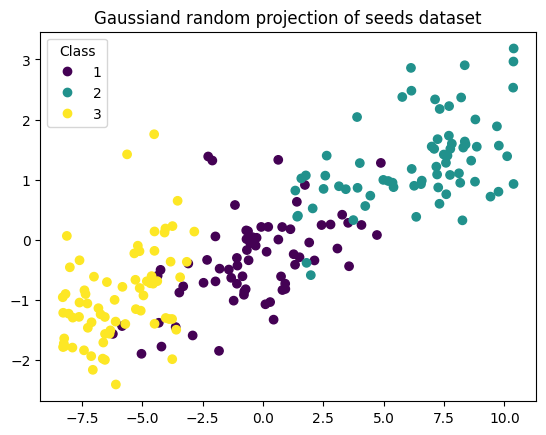

In [110]:
# Codegrade Tag Question3c
# Do *not* remove the tag above
from sklearn.random_projection import GaussianRandomProjection
import matplotlib.pyplot as plt

grp = GaussianRandomProjection(n_components=2, random_state=0)

X_gauss = grp.fit_transform(X)

fig, ax_gauss = plt.subplots()

scatter = ax_gauss.scatter(X_gauss[:,0], X_gauss[:,1], c=y)

ax_gauss.set_title("Gaussiand random projection of seeds dataset")

ax_gauss.legend(
    *scatter.legend_elements(),
    title="Class"
)

plt.show()

### 手肘法（Elbow Method）決定最佳群數

對 k=1 至 30 分別執行 K-Means，繪製慣性（Inertia）曲線。曲線在 k=3 附近出現明顯轉折（手肘），之後降幅趨緩，顯示選擇 **k=3** 在解釋力與模型複雜度之間取得最佳平衡——恰好對應資料中三種小麥品種。

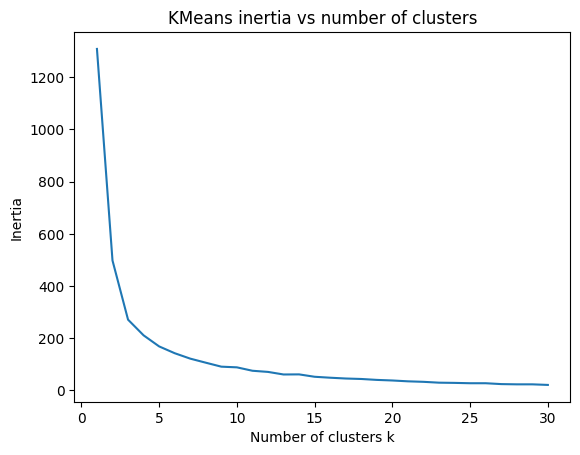

In [111]:
# Codegrade Tag Question4
# Do *not* remove the tag above
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

k_range = range(1,31)

inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=1234+k)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, ax_kclusters = plt.subplots()
ax_kclusters.plot(k_range, inertias)
ax_kclusters.set_xlabel("Number of clusters k")
ax_kclusters.set_ylabel("Inertia")
ax_kclusters.set_title("KMeans inertia vs number of clusters")
plt.show()

### Rand 指數：評估分群與真實標籤的一致性

Rand 指數衡量每一對資料點在兩種分群下「同群/異群」的一致比例，範圍 [0, 1]，越接近 1 代表越吻合。以 k=3、隨機種子 112233 執行 K-Means 後，與真實類別標籤計算 Rand 指數。

In [112]:
# Codegrade Tag Question5
# Do *not* remove the tag above
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score
import numpy as np 

k = len(np.unique(y))
kmeans = KMeans(n_clusters=k, random_state=112233)
kmeans.fit(X_pca)

labels = kmeans.labels_

rand_index = rand_score(y, labels)

print(rand_index)

0.9048986101617681


### 最佳排列準確率（Permutation Accuracy）

分群演算法輸出的群標籤無固定語義（群 0 不一定對應類別 1），因此窮舉所有 3!=6 種標籤對應排列，找出使預測與真實標籤最吻合的排列，計算最高準確率。

In [113]:
#Codegrade Tag Question6
# Do *not* remove the tag above
import numpy as np
from itertools import permutations

k = len(np.unique(y))  # number of clusters and classes
best_accuracy = 0.0

cluster_ids = sorted(np.unique(labels))
true_ids = sorted(np.unique(y))

for perm in permutations(true_ids, k):
    mapping = {cid: perm[i] for i, cid in enumerate(cluster_ids)}
    mapped = np.vectorize(mapping.get)(labels)

    accr = np.mean(mapped == y)
    if accr > best_accuracy:
        best_accuracy = accr

accuracy = best_accuracy
print("CLuster accuracy:", accuracy)

CLuster accuracy: 0.9238095238095239


### 分群結果分析

K-Means 在本資料集上表現良好：Rand 指數約 0.90，最佳排列準確率約 0.92，顯示絕大多數資料點被正確歸類至其所屬的小麥品種。

PCA 投影圖（第 3b 節）可見三類之間仍有少量重疊，這是影響分群精度的主要原因。手肘法正確偵測出 k=3 為最適群數，不同隨機種子對結果的影響相對有限，顯示三群結構在資料中十分穩健。

# 迴歸分析（Regression）

## 手刻簡單線性迴歸：

以封閉解（Closed-Form Solution）實作一元線性迴歸 y = α + βx：

- **β**（斜率）= Σ(xᵢ−x̄)(yᵢ−ȳ) / Σ(xᵢ−x̄)²
- **α**（截距）= ȳ − β·x̄

 以 ndarray 儲存斜率， 以浮點數儲存截距， 則計算給定輸入的預測值。

In [114]:
# Codegrade Tag Question8
# Do *not* remove the tag above
# Implement the class below

import numpy as np

class SimpleLinearRegression:
    """
    Uses closed-form formulae to implement the simple linear regression using least squares.
    """

    def fit(self,X,y):
        """
        Fits the model on the observations (X,y) using least squares.

        Parameters:
        - X : n*1 array of univariate observations (independent variable)
        - y : n array of univariate observations (dependent variable)

        Return value:
        - Returns self
        """
        assert isinstance(X,np.ndarray) and isinstance(y,np.ndarray)
        assert X.ndim == 2 and y.ndim == 1
        assert X.shape[0] == y.shape[0] and X.shape[1] == 1

        

        x = X[:,0] #flatten the array out to one dimention
        x_mean = np.mean(x)
        y_mean = np.mean(y)


        #calculate the coeficiant 
    
        numerator = np.sum((x-x_mean) * (y-y_mean))  
        denominator = np.sum((x-x_mean)**2) 
        self.coef_ = np.array([numerator/denominator])
        
        #calculate the intercept
        self.intercept_ = float(y_mean - (numerator/denominator)*x_mean)

        return self

    def predict(self,X):
        """
        Returns model predictions y = a+b*x for all observations given as input.

        Parameters:
        - X : n*1 array of univariate observations

        Return value:
        - An array of length n of predictions
        """
        assert isinstance(X,np.ndarray)
        assert X.ndim == 2 and X.shape[1] == 1

        x = X[:,0] #flatten to a arrray of one dimantion

        return (self.intercept_ + self.coef_[0] * x) # return the regression line alpha + betha * x


## 訓練/測試資料集分割與特徵相關性分析

以 75%/25% 比例切分資料（隨機種子 22）。接著對訓練集計算所有數值特徵與 （緊密度）的皮爾森相關係數，找出相關性絕對值最高的特徵，作為後續迴歸的輸入變數。

In [115]:
# Codegrade Tag Question9
# Do *not* remove the tag above
# Write your code below
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.25, random_state=22) #make the train/test splitt

correlation_matrix = df_train.corr(method="pearson") #make a correlation matrix with the person method

compactness_corr = correlation_matrix["compactness"].drop("compactness") #exstract the compactness correlations and drop the one where it chechs the correleation with itself 
most_correlated_feature = compactness_corr.abs().idxmax() #get the name of the feature with the biggest absolute correlation

most_correlated_feature_corr = compactness_corr[most_correlated_feature] #get the correlation coefficien of the most correlated feature


## 模型訓練與評估指標

以最高相關特徵預測 ，訓練  後計算：
- **R²**（訓練集）：解釋變異比例
- **RMS**（測試集）：均方根誤差
- **MAE**（測試集）：平均絕對誤差
- **MAPE**（測試集）：平均絕對百分比誤差

In [116]:
# Codegrade Tag Question10
# Do *not* remove the tag above
# Write your code below
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Make the train and test data to be arrays and not dataframes
X_train = df_train[[most_correlated_feature]].to_numpy()  # n×1 
y_train = df_train['compactness'].to_numpy()              # n
X_test = df_test[[most_correlated_feature]].to_numpy()
y_test = df_test['compactness'].to_numpy()

model = SimpleLinearRegression()
model.fit(X_train, y_train)

#calculate the R2 with respect to the training set
y_predict_train = model.predict(X_train)
r2 = r2_score(y_train, y_predict_train)

#predict the y of the test set
y_predict_test = model.predict(X_test)

rms = root_mean_squared_error(y_test, y_predict_test)
mae = mean_absolute_error(y_test, y_predict_test)
mape = mean_absolute_percentage_error(y_test, y_predict_test)

print("r2:",r2)
print("rms:", rms)
print("mae:", mae)
print("mape:", mape)

r2: 0.5701161710978071
rms: 0.01468202230040411
mae: 0.012104324963013984
mape: 0.013940914488948398


## 迴歸直線視覺化

將測試集散佈圖與訓練後的迴歸直線（紅色虛線）疊加繪製，直觀呈現模型在測試資料上的擬合情況。

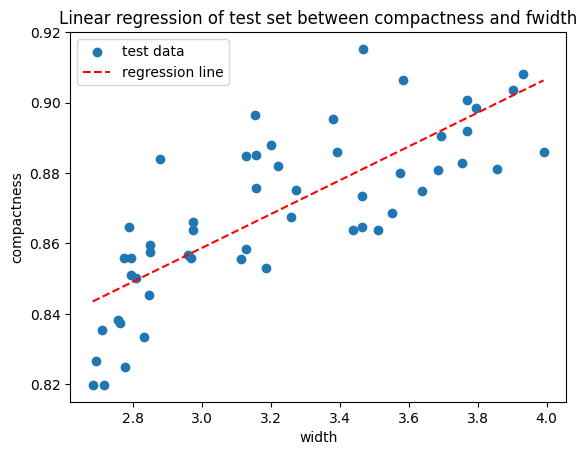

In [117]:
# Codegrade Tag Question11
# Do *not* remove the tag above
# Write your code below
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.scatter(X_test, y_test, label = "test data")

#regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
ax.plot(x_line, y_line, "r--", label = "regression line")

ax.set_xlabel(most_correlated_feature)
ax.set_ylabel("compactness")
ax.set_title(f"Linear regression of test set between compactness and f{most_correlated_feature}")
ax.legend()

plt.show()

## 模型評估與討論

R²≈0.57 顯示該單一特徵能解釋約 57% 的緊密度變異，模型具備一定的預測能力但仍有改進空間。MAPE 約 1.4%，絕對誤差相對原始值較小，說明在整體趨勢捕捉上表現尚可。

從散佈圖可見部分離群點導致迴歸直線在低值區段偏高，使用穩健迴歸（例如 Huber loss）或引入更多特徵進行多元線性迴歸，皆可有效提升預測精度。線性迴歸的優勢在於係數可直接詮釋：斜率的大小直接說明該特徵每單位變化對緊密度的影響程度。